In [2]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [3]:
control = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_controltow_flux.csv')
array = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_arraytow_flux.csv')

control_NR =pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_controltow_netrad.csv')
array_NR =pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_arraytow_netrad.csv')


control['dt_ts'] = pd.to_datetime(control['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6)
r = pd.date_range(start=dt.datetime(2025, 1, 1), end=control.dt_ts.max(), freq = '30min') 
control = control.set_index('dt_ts').reindex(r).rename_axis('dt_ts')

# control_NR = control_NR.map(lambda x: np.nan if x == -9999 else x) #Convert -9999s to NaNs
control_NR['dt_ts'] = pd.to_datetime(control_NR['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6) #same note as above about timeshift
control_NR = control_NR.set_index('dt_ts').reindex(r).rename_axis('dt_ts')

#Array tower dataset
# array = array.map(lambda x: np.nan if x == -9999 else x) #Convert -9999s to NaNs
array['dt_ts'] = pd.to_datetime(array['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6) #same note as above about timeshift
array = array.set_index('dt_ts').reindex(r).rename_axis('dt_ts')

# array_NR = array_NR.map(lambda x: np.nan if x == -9999 else x) #Convert -9999s to NaNs
array_NR['dt_ts'] = pd.to_datetime(array_NR['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6) #same note as above about timeshift
array_NR = array_NR.set_index('dt_ts').reindex(r).rename_axis('dt_ts')

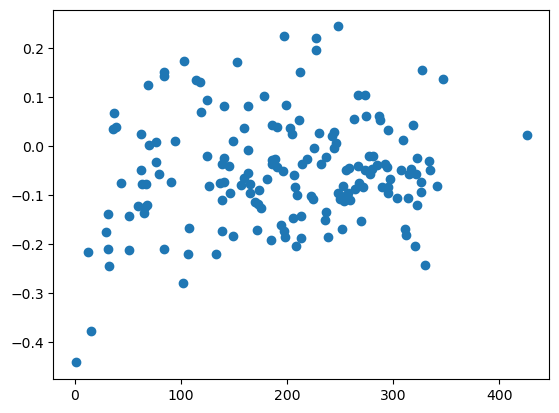

In [28]:
startdate = dt.datetime(2025, 6, 25)
enddate = dt.datetime(2025, 7, 15)
w_diff = array['Uz_Avg'] - control['Uz_Avg']
plt.scatter(array_NR['apSWIn_Avg'].groupby(array.index.date).mean(), w_diff.groupby(array.index.date).mean())

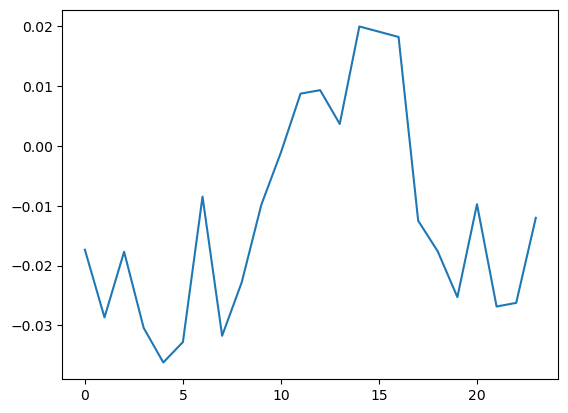

In [29]:
plt.plot(w_diff[startdate:enddate].groupby(w_diff[startdate:enddate].index.hour).mean())